# Actividad 2: Clustering no supervisado

- Alex Rubiño Fernández
- Aprendizaje Automático 2
- 11/05/2026
- UNIR

## Índice

1. [Ejercicio 1: Generación y visualización del dataset](#ejercicio-1-generación-y-visualización-del-dataset)
2. [Ejercicio 2: SVM con kernel lineal y ajuste de hiperparámetros](#ejercicio-2-svm-con-kernel-lineal-y-ajuste-de-hiperparámetros)
3. [Ejercicio 3: SVM con kernels no lineales y ajuste de hiperparámetros](#ejercicio-3-svm-con-kernels-no-lineales-y-ajuste-de-hiperparámetros)
4. [Ejercicio 4: Visualización de fronteras de decisión y comparativa de rendimiento](#ejercicio-4-visualización-de-fronteras-de-decisión-y-comparativa-de-rendimiento)
5. [Ejercicio 5: Discusión y comparación de resultados](#ejercicio-5-discusión-y-comparación-de-resultados)

## Ejercicio 1: Generación y visualización del dataset

Generamos un dataset sintético con las siguientes características: dos círculos concéntricos con grosor aleatorio, tres círculos adicionales también con grosor aleatorio (algunos de ellos se cortan entre sí y con los círculos concéntricos), y seis bloques compactos distribuidos entre los círculos anteriores. Por último, visualizamos el dataset resultante.

Para ello, creamos una función generar_circulo que genera puntos alrededor de un círculo con ruido gaussiano para simular el grosor. Generamos dos círculos concéntricos centrados en (0,0) con radios 1.0 y 1.8 respectivamente, ambos con 400 puntos y un grosor de 0.08. A continuación, generamos tres círculos adicionales: el círculo 3 centrado en (2.2, 1.2) con radio 0.9, el círculo 4 en (1.8, -1.5) con radio 0.8, y el círculo 5 en (-2.0, 1.3) con radio 0.8, todos ellos con grosor 0.07 y 300 puntos cada uno. Para los seis bloques compactos, utilizamos make_blobs generando 60 muestras alrededor de cada centro, con una desviación estándar de 0.08. Los centros de los bloques son: (0.6, 1.3), (-0.7, 1.4), (1.3, -0.6), (-1.2, -0.7), (1.4, 0.7) y (-1.4, 0.9). Finalmente, combinamos todos los puntos en un único dataset sin etiquetas (aprendizaje no supervisado) y mostramos los datos en un gráfico de dispersión.

Círculo 1 (interior): 400 puntos
Círculo 2 (exterior): 400 puntos
Círculo 3: 300 puntos
Círculo 4: 300 puntos
Círculo 5: 300 puntos
Bloque 1: 60 puntos en (0.6, 1.3)
Bloque 2: 60 puntos en (-0.7, 1.4)
Bloque 3: 60 puntos en (1.3, -0.6)
Bloque 4: 60 puntos en (-1.2, -0.7)
Bloque 5: 60 puntos en (1.4, 0.7)
Bloque 6: 60 puntos en (-1.4, 0.9)

Total puntos en bloques compactos: 360
Dataset final: 2060 muestras, 2 características
NOTA: No se incluyen etiquetas (aprendizaje no supervisado)


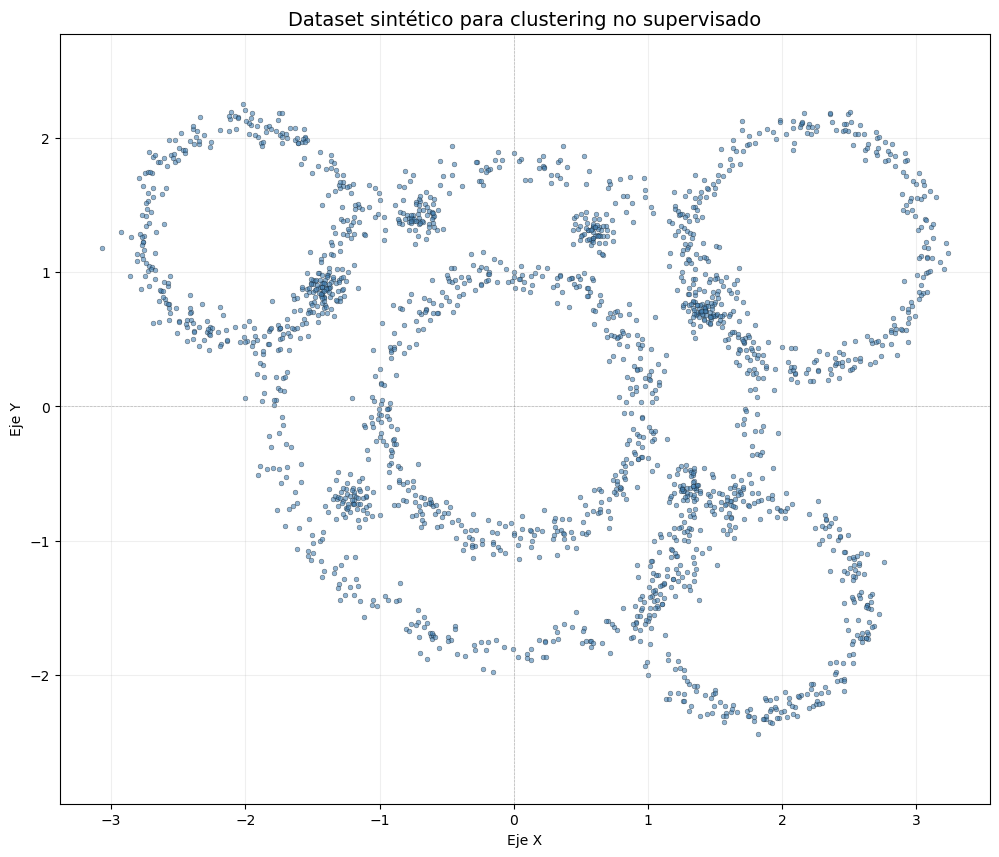

In [6]:
# Importamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Fijamos semilla para reproducibilidad
np.random.seed(42)

def generar_circulo(centro_x, centro_y, radio, n_puntos, grosor):
    """
    Genera puntos alrededor de un círculo con grosor (ruido gaussiano)
    """
    angulos = np.random.uniform(0, 2*np.pi, n_puntos)
    r = radio + np.random.normal(0, grosor, n_puntos)
    x = centro_x + r * np.cos(angulos)
    y = centro_y + r * np.sin(angulos)
    return np.column_stack([x, y])

# Dos círculos concéntricos en (0,0)
circulo1 = generar_circulo(0, 0, 1.0, 400, 0.08)
circulo2 = generar_circulo(0, 0, 1.8, 400, 0.08)

print(f"Círculo 1 (interior): {circulo1.shape[0]} puntos")
print(f"Círculo 2 (exterior): {circulo2.shape[0]} puntos")

# Círculo 3 - se corta con el círculo 2
circulo3 = generar_circulo(2.2, 1.2, 0.9, 300, 0.07)

# Círculo 4 - se corta con el círculo 1 y 2
circulo4 = generar_circulo(1.8, -1.5, 0.8, 300, 0.07)

# Círculo 5 - se corta con el círculo 2
circulo5 = generar_circulo(-2.0, 1.3, 0.8, 300, 0.07)

print(f"Círculo 3: {circulo3.shape[0]} puntos")
print(f"Círculo 4: {circulo4.shape[0]} puntos")
print(f"Círculo 5: {circulo5.shape[0]} puntos")

# Posiciones de los 6 bloques compactos
centros_blobs = [
    (0.6, 1.3), (-0.7, 1.4), (1.3, -0.6),
    (-1.2, -0.7), (1.4, 0.7), (-1.4, 0.9)
]

bloques = []
for i, centro in enumerate(centros_blobs):
    blob, _ = make_blobs(n_samples=60, centers=[centro], cluster_std=0.08, n_features=2)
    bloques.append(blob)
    print(f"Bloque {i+1}: {blob.shape[0]} puntos en {centro}")

# Unir todos los bloques en un solo array
bloques_compactos = np.vstack(bloques)
print(f"\nTotal puntos en bloques compactos: {bloques_compactos.shape[0]}")
# Unir todos los componentes
X = np.vstack([circulo1, circulo2, circulo3, circulo4, circulo5, bloques_compactos])

print(f"Dataset final: {X.shape[0]} muestras, {X.shape[1]} características")
print("NOTA: No se incluyen etiquetas (aprendizaje no supervisado)")

plt.figure(figsize=(12, 10))

plt.scatter(X[:, 0], X[:, 1], s=12, alpha=0.6, c='steelblue', edgecolors='k', linewidth=0.3)

plt.title('Dataset sintético para clustering no supervisado', fontsize=14)
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.axis('equal')
plt.grid(alpha=0.2)
plt.show()

